# Sanity check for reconfirming loss of large scale chain
Niya Shao
5/08/26

Run the sanity check to visualize the reduction of loss in the large-scale chains.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from pathlib import Path

In [6]:
# load compiled dataset that contain data needed for calculating mass flux residuals
df = pd.read_csv('./data/griddedData/Support_Force.csv')

# define location of the largeScaleChain_multiprocessing.py file
# please make sure this file is consistent with the one loaded on onedrive
python_script_location = 'largeScaleChain_multiprocessing.py'

# load an example large-scale chain output
lsc_bed = np.load('./data/Support_Force/LargeScaleChain/209073/bed_110k.npy')

In [7]:
# load sigma_mc value from largeScaleChain_multiprocessing.py file
keyword = 'sigma_mc'
with open(python_script_location, "r", encoding="utf-8") as file:
    for line_number, line in enumerate(file, start=1):
        if keyword in line:
            print(f"Line {line_number}: {line.strip()}")

Line 541: largeScaleChain.set_loss_type(sigma_mc=1.50, massConvInRegion=True)


In [8]:
# write the sigma_mc you used for the large scale chain
sigma_mc = 2.5

In [9]:
# load the result from large scale chain
# download the result to check from onedrive
result = np.load('./data/Support_Force/LargeScaleChain/209073/results_200k.npz')

# load loss from one large-scale chain
loss = result['loss']

In [10]:
# define functions used to calculate loss
def get_mass_flux_residual(bed, surf, velx, vely, dhdt, smb, resolution):
    thick = surf - bed
    
    dx = np.gradient(velx*thick, resolution, axis=1)
    dy = np.gradient(vely*thick, resolution, axis=0)
    
    res = dx + dy + dhdt - smb
    
    return res

def calculate_loss(mass_flux_residuals, highvel_region, sigma_mc):
    loss = np.nansum(np.square(mass_flux_residuals[highvel_region == 1]))  / (2*sigma_mc**2)
    return loss

In [11]:
# create a grid of x and y coordinates
x_uniq = np.unique(df.x)
y_uniq = np.unique(df.y)

resolution = 500

xx, yy = np.meshgrid(x_uniq, y_uniq)

# load information required for calculating mass flux residuals
dhdt = df['dhdt'].values.reshape(xx.shape)
smb = df['smb'].values.reshape(xx.shape)
velx = df['velx'].values.reshape(xx.shape)
vely = df['vely'].values.reshape(xx.shape)
surf = df['bedmap_surf'].values.reshape(xx.shape)
highvel_mask = df['highvel_mask'].values.reshape(xx.shape)
bedmachine_bed = df['bedmachine_bed'].values.reshape(xx.shape)

In [12]:
# with the sigma_mc, we can calculate loss for BedMachine topogrpahy
bedmachine_mass_flux_residuals = get_mass_flux_residual(bedmachine_bed, surf, velx, vely, dhdt, smb, resolution)
bedmachine_loss = calculate_loss(bedmachine_mass_flux_residuals, highvel_mask, sigma_mc)

In [13]:
# calculate the loss from one of the large-scale chains
# make sure that it is consistent with loaded loss from results.npz
lsc_mass_flux_residuals = get_mass_flux_residual(lsc_bed, surf, velx, vely, dhdt, smb, resolution)
lsc_bed_loss = calculate_loss(lsc_mass_flux_residuals, highvel_mask, sigma_mc)

Plot and compare loss. Make sure to change your glacier name!

Text(0.5, 1.0, 'Loss Comparison for Totten Glacier')

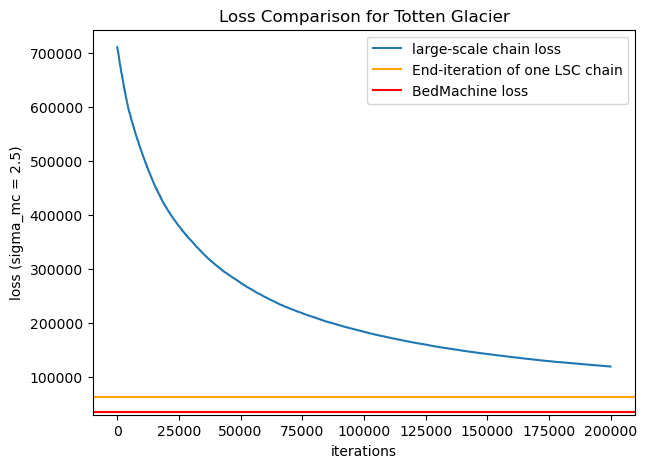

In [14]:
plt.figure(figsize=(7,5))
plt.plot(loss,label='large-scale chain loss')
plt.axhline(lsc_bed_loss,color='orange',label='End-iteration of one LSC chain')
plt.axhline(bedmachine_loss,color='red',label='BedMachine loss')
plt.xlabel('iterations')
plt.ylabel('loss (sigma_mc = ' + str(sigma_mc) + ')')
plt.legend()
plt.title('Loss Comparison for Totten Glacier')

If you have LargeScaleChain folder, you can check for loss of every large scale chain

In [15]:
# provide the folder that the code will search results
large_scale_chain_folder = './data/Support_Force/LargeScaleChain'

# provide the name of the result file
result_file_name = 'results_200k.npz'

In [16]:
# load the path of all the results
# this code will search in 'large_scale_chain_folder'
# and find every files that has the name 'result_file_name'
folder = Path(large_scale_chain_folder)
result_locations = [str(path) for path in folder.rglob(result_file_name)]

# result_locations is simply a list of strings, where each string is the location of the result file
print('the file locations are ', result_locations)

the file locations are  ['data/Support_Force/LargeScaleChain/821861/results_200k.npz', 'data/Support_Force/LargeScaleChain/973960/results_200k.npz', 'data/Support_Force/LargeScaleChain/315470/results_200k.npz', 'data/Support_Force/LargeScaleChain/125068/results_200k.npz', 'data/Support_Force/LargeScaleChain/209073/results_200k.npz', 'data/Support_Force/LargeScaleChain/842002/results_200k.npz', 'data/Support_Force/LargeScaleChain/165589/results_200k.npz', 'data/Support_Force/LargeScaleChain/654803/results_200k.npz', 'data/Support_Force/LargeScaleChain/271381/results_200k.npz', 'data/Support_Force/LargeScaleChain/157654/results_200k.npz']


In [17]:
# if unable to download the entire LargeScaleChain folder, you can download individual files
# and modify 'result_locations' list

# result_locations = ['file_locations']

In [18]:
# load all the loss
loss_list = []

for path in result_locations:
    result = np.load(path)
    loss_list.append(result['loss'])

loss_list = np.array(loss_list)

Text(0.5, 1.0, 'Loss Comparison for Support Force Glacier')

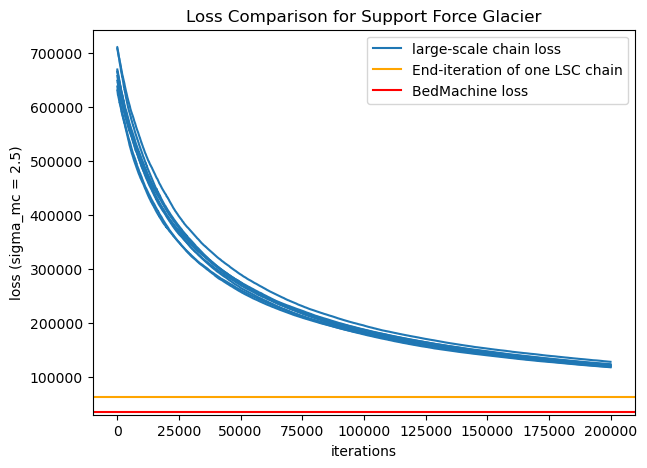

In [19]:
plt.figure(figsize=(7,5))
for l in loss_list[:-2]:
   plt.plot(l,color='tab:blue')
plt.plot(loss_list[-1],color='tab:blue',label='large-scale chain loss')
plt.axhline(lsc_bed_loss,color='orange',label='End-iteration of one LSC chain')
plt.axhline(bedmachine_loss,color='red',label='BedMachine loss')
plt.xlabel('iterations')
plt.ylabel('loss (sigma_mc = ' + str(sigma_mc) + ')')
plt.legend()
plt.title('Loss Comparison for Support Force Glacier')